# 📊 Day 18 — Linear Regression Deep Dive
### 100 Days of Data Science | by Shoaib Aslam

---

## Table of Contents

1️⃣ What is Linear Regression  
2️⃣ How It Works — The Math  
3️⃣ Loading & Preparing the Data  
4️⃣ Simple Linear Regression  
5️⃣ Evaluating the Model  
6️⃣ Multiple Linear Regression  
7️⃣ Checking Assumptions  
8️⃣ Improving the Model  
9️⃣ Residual Analysis  
🔟 When to Use What  

---
## 1️⃣ What is Linear Regression?

Linear Regression is a supervised ML algorithm that predicts a **continuous numerical value** by finding the best straight line through the data.

Examples:
- Predict house price from size
- Predict salary from experience
- Predict wine price from points

> **Key idea:** Linear Regression finds the line that minimizes the total error between predicted and actual values.

---
## 2️⃣ How It Works — The Math

The formula for a straight line is:

```
y = mx + b
```

In ML terms:

```
y = β0 + β1*x1 + β2*x2 + ... + ε
```

| Term | Meaning |
|------|---------|
| `y` | Target variable (what we predict) |
| `β0` | Intercept (value of y when x = 0) |
| `β1` | Coefficient (slope — how much y changes per unit of x) |
| `x1` | Feature (input variable) |
| `ε` | Error term (noise in data) |

The model learns the best values of β0 and β1 by minimizing the **Sum of Squared Errors (SSE)**.

---
## 3️⃣ Loading & Preparing the Data

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Winemag dataset
df = pd.read_csv(r"C:\Users\aslam\Downloads\winemag-data-130k-v2.csv\winemag-data-130k-v2.csv", index_col=0)
df.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [3]:
# Keep relevant columns and drop missing values
df = df[['points', 'price', 'country', 'variety']].dropna()
print("Shape:", df.shape)
df.head()

Shape: (120915, 4)


,points,price,country,variety
1,87,15.0,Portugal,Portuguese Red
2,87,14.0,US,Pinot Gris
3,87,13.0,US,Riesling
4,87,65.0,US,Pinot Noir
5,87,15.0,Spain,Tempranillo-Merlot


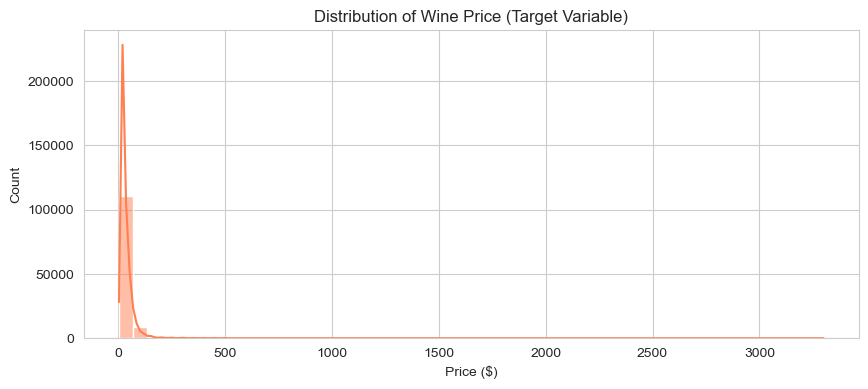

In [4]:
# Quick look at target variable distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['price'], bins=50, kde=True, color='coral')
plt.title("Distribution of Wine Price (Target Variable)")
plt.xlabel("Price ($)")
plt.show()

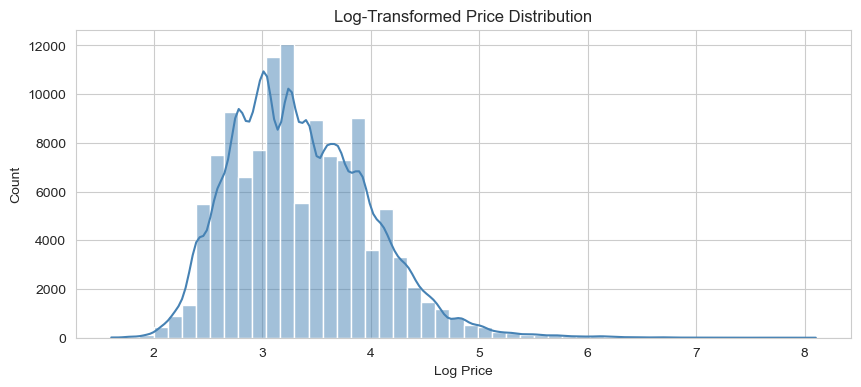

In [5]:
# Price is right-skewed — apply log transformation to normalize it
df['log_price'] = np.log1p(df['price'])

plt.figure(figsize=(10, 4))
sns.histplot(df['log_price'], bins=50, kde=True, color='steelblue')
plt.title("Log-Transformed Price Distribution")
plt.xlabel("Log Price")
plt.show()

---
## 4️⃣ Simple Linear Regression

Simple Linear Regression uses **one feature** to predict the target.

In [6]:
# Feature and target
X_simple = df[['points']]
y = df['log_price']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (96732, 1)
Test size: (24183, 1)


In [7]:
# Train Simple Linear Regression
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

print("Intercept (β0):", round(model_simple.intercept_, 4))
print("Coefficient (β1):", round(model_simple.coef_[0], 4))
print("\nFormula: log_price =", round(model_simple.intercept_, 4), "+", round(model_simple.coef_[0], 4), "* points")

Intercept (β0): -7.8414
Coefficient (β1): 0.1267

Formula: log_price = -7.8414 + 0.1267 * points


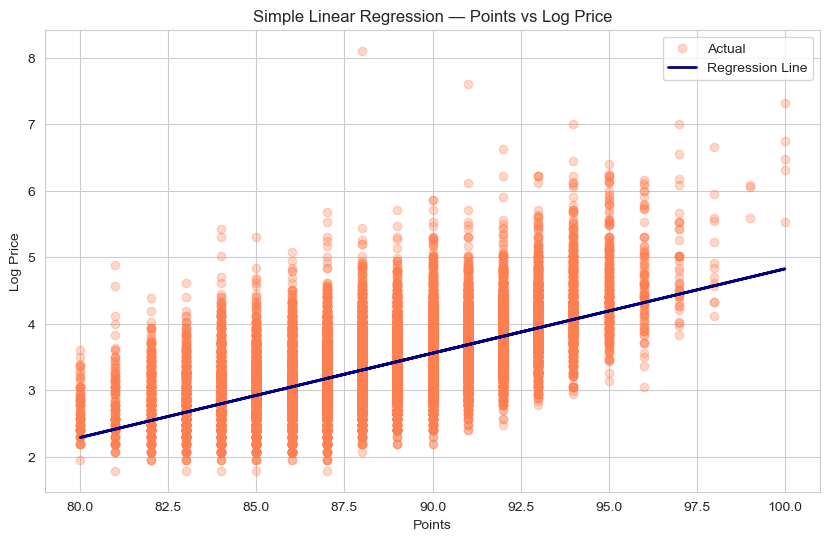

In [8]:
# Visualize the regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='coral', alpha=0.3, label='Actual')
plt.plot(X_test, model_simple.predict(X_test), color='navy', linewidth=2, label='Regression Line')
plt.title("Simple Linear Regression — Points vs Log Price")
plt.xlabel("Points")
plt.ylabel("Log Price")
plt.legend()
plt.show()

---
## 5️⃣ Evaluating the Model

We use four metrics to measure how well the model is performing.

In [9]:
# Predictions
y_pred_simple = model_simple.predict(X_test)

# Evaluation metrics
mae  = mean_absolute_error(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_simple)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.3938
MSE  : 0.2483
RMSE : 0.4983
R²   : 0.3764


#### What just happened? 🤔

| Metric | Meaning | Ideal |
|--------|---------|-------|
| MAE | Average absolute error | As low as possible |
| MSE | Penalizes large errors more heavily | As low as possible |
| RMSE | Error in same unit as target | As low as possible |
| R² | % of variance explained by model | Closer to 1.0 is better |

---
## 6️⃣ Multiple Linear Regression

Multiple Linear Regression uses **more than one feature** to predict the target — almost always performs better.

In [10]:
# Feature Engineering — encode country and variety
from sklearn.preprocessing import LabelEncoder

le_country = LabelEncoder()
le_variety = LabelEncoder()

df['country_encoded'] = le_country.fit_transform(df['country'])
df['variety_encoded'] = le_variety.fit_transform(df['variety'])

df.head(3)

,points,price,country,variety,log_price,country_encoded,variety_encoded
1,87,15.0,Portugal,Portuguese Red,2.772589,30,442
2,87,14.0,US,Pinot Gris,2.708050,39,428
3,87,13.0,US,Riesling,2.639057,39,471


In [11]:
# Multiple features
X_multi = df[['points', 'country_encoded', 'variety_encoded']]
y = df['log_price']

# Train test split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_m = scaler.fit_transform(X_train_m)
X_test_m  = scaler.transform(X_test_m)

In [12]:
# Train Multiple Linear Regression
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# Evaluate
y_pred_multi = model_multi.predict(X_test_m)

print("Multiple Linear Regression Results:")
print(f"MAE  : {mean_absolute_error(y_test_m, y_pred_multi):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test_m, y_pred_multi)):.4f}")
print(f"R²   : {r2_score(y_test_m, y_pred_multi):.4f}")

Multiple Linear Regression Results:
MAE  : 0.3861
RMSE : 0.4914
R²   : 0.3936


In [13]:
# Compare Simple vs Multiple Linear Regression
comparison = pd.DataFrame({
    'Model'  : ['Simple LR (1 feature)', 'Multiple LR (3 features)'],
    'MAE'    : [mean_absolute_error(y_test, y_pred_simple),
                mean_absolute_error(y_test_m, y_pred_multi)],
    'RMSE'   : [np.sqrt(mean_squared_error(y_test, y_pred_simple)),
                np.sqrt(mean_squared_error(y_test_m, y_pred_multi))],
    'R²'     : [r2_score(y_test, y_pred_simple),
                r2_score(y_test_m, y_pred_multi)]
}).round(4)

comparison

,Model,MAE,RMSE,R²
0,Simple LR (1 feature),0.3938,0.4983,0.3764
1,Multiple LR (3 features),0.3861,0.4914,0.3936


---
## 7️⃣ Checking Assumptions

Linear Regression works best when 4 key assumptions are met.

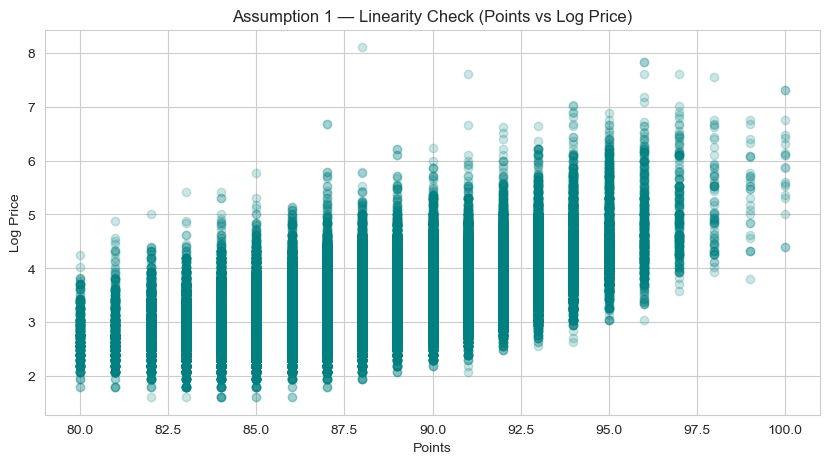

In [14]:
# Assumption 1 — Linearity
# Check if features have a linear relationship with target
plt.figure(figsize=(10, 5))
plt.scatter(df['points'], df['log_price'], alpha=0.2, color='teal')
plt.title("Assumption 1 — Linearity Check (Points vs Log Price)")
plt.xlabel("Points")
plt.ylabel("Log Price")
plt.show()

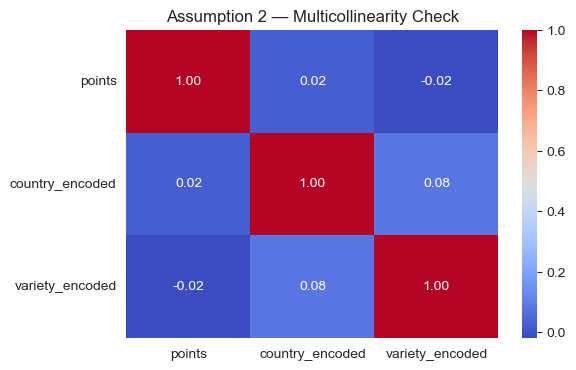

In [15]:
# Assumption 2 — No Multicollinearity
# Features should not be highly correlated with each other
corr = df[['points', 'country_encoded', 'variety_encoded']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Assumption 2 — Multicollinearity Check")
plt.show()

#### 💡 The 4 Assumptions of Linear Regression

| Assumption | What to Check | How to Fix if Violated |
|------------|---------------|------------------------|
| Linearity | Scatter plot of X vs y | Apply log or polynomial transformation |
| No multicollinearity | Correlation heatmap between features | Drop or combine correlated features |
| Homoscedasticity | Residual plot (spread should be even) | Transform target variable |
| Normality of residuals | Histogram of residuals | Remove outliers or transform features |

---
## 8️⃣ Improving the Model

Cross-validation gives a more reliable performance estimate than a single train-test split.

In [16]:
# Cross Validation — 5 fold
X_cv = scaler.fit_transform(df[['points', 'country_encoded', 'variety_encoded']])
y_cv = df['log_price']

cv_scores = cross_val_score(LinearRegression(), X_cv, y_cv, cv=5, scoring='r2')

print("Cross Validation R² Scores:", cv_scores.round(4))
print("Mean R²:", cv_scores.mean().round(4))
print("Std Dev:", cv_scores.std().round(4))

Cross Validation R² Scores: [0.387  0.3992 0.366  0.3929 0.398 ]
Mean R²: 0.3886
Std Dev: 0.0121


C:\Users\aslam\AppData\Local\Temp\ipykernel_12844\3037231318.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance, x='Coefficient', y='Feature', palette='coolwarm')


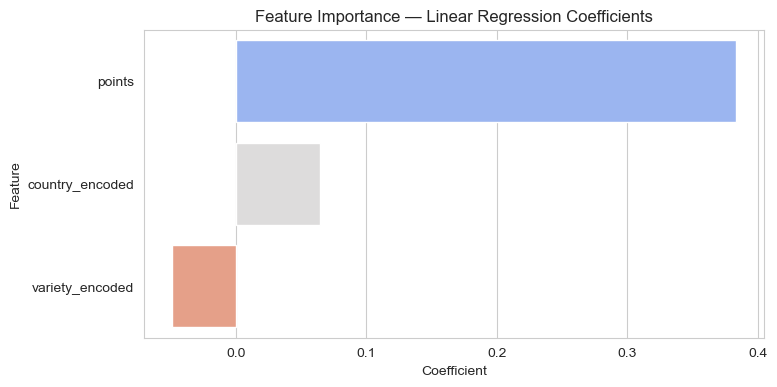

In [17]:
# Feature importance — coefficients
feature_names = ['points', 'country_encoded', 'variety_encoded']
coefficients  = model_multi.coef_

feat_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
feat_importance = feat_importance.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=feat_importance, x='Coefficient', y='Feature', palette='coolwarm')
plt.title("Feature Importance — Linear Regression Coefficients")
plt.show()

---
## 9️⃣ Residual Analysis

Residuals are the difference between actual and predicted values. Analyzing them reveals model weaknesses.

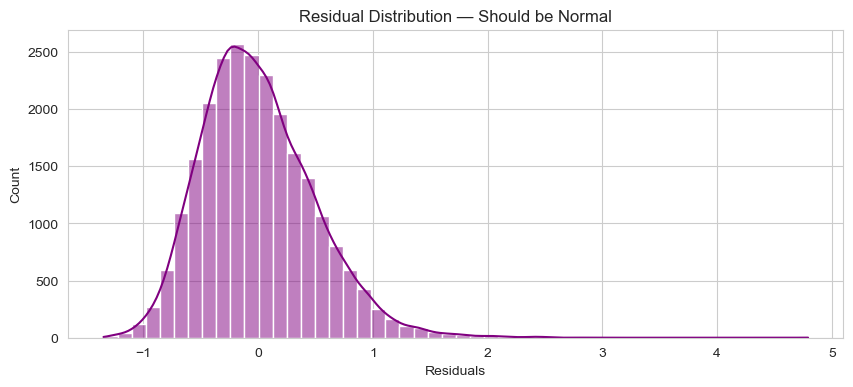

In [18]:
# Calculate residuals
residuals = y_test_m - y_pred_multi

# Plot residuals distribution
plt.figure(figsize=(10, 4))
sns.histplot(residuals, kde=True, color='purple', bins=50)
plt.title("Residual Distribution — Should be Normal")
plt.xlabel("Residuals")
plt.show()

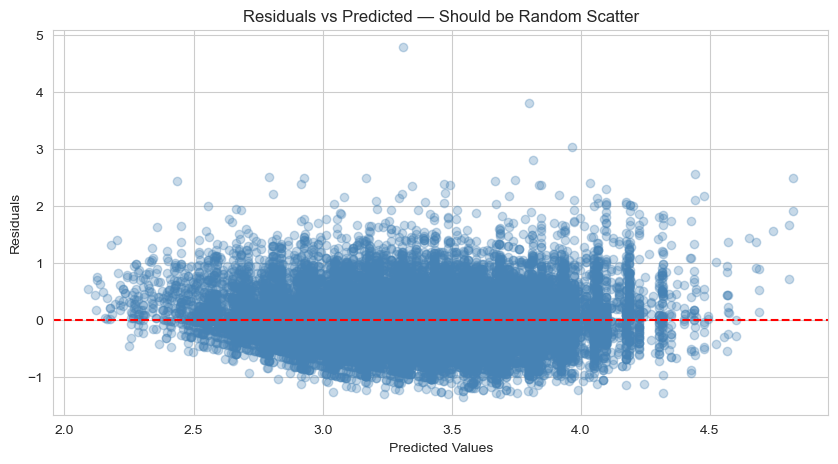

In [19]:
# Residuals vs Predicted — check for patterns
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_multi, residuals, alpha=0.3, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title("Residuals vs Predicted — Should be Random Scatter")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

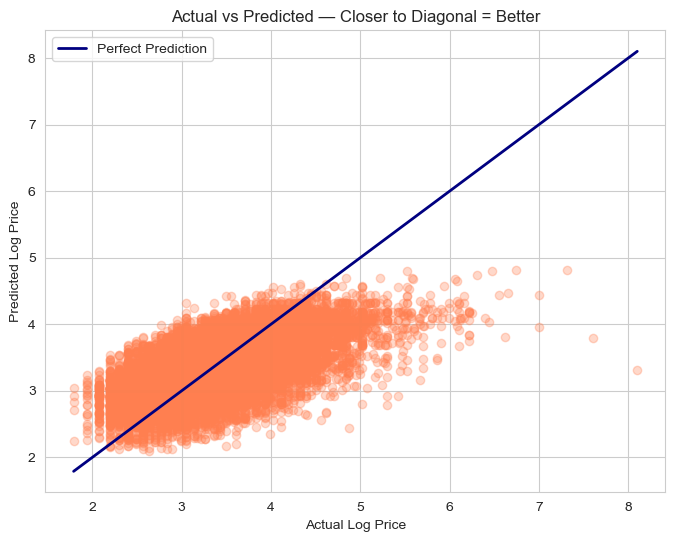

In [20]:
# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_m, y_pred_multi, alpha=0.3, color='coral')
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'navy', linewidth=2, label='Perfect Prediction')
plt.title("Actual vs Predicted — Closer to Diagonal = Better")
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.legend()
plt.show()

---
## 🔟 When to Use What

| Situation | What to Do |
|-----------|------------|
| One feature, predict number | Simple Linear Regression |
| Multiple features, predict number | Multiple Linear Regression |
| Target is right-skewed | Apply `np.log1p()` transformation |
| Features have different scales | Apply `StandardScaler` before training |
| Want reliable performance estimate | Use `cross_val_score` with 5 folds |
| Residuals show a pattern | Model is missing important features |
| R² is low | Add more features or try a different model |

---
## 🔑 Key Takeaways

→ Linear Regression finds the best straight line through data by minimizing squared errors  
→ Always check if the target variable is normally distributed — log transform if skewed  
→ Multiple features almost always improve the model over a single feature  
→ Always scale features before training with `StandardScaler`  
→ R² tells you how much of the variation the model explains  
→ Cross-validation gives a more honest performance estimate than one split  
→ Residuals should be normally distributed and random — if not, the model has issues  
→ Feature coefficients tell you which features matter most to the prediction

---
## 📁 Connect & Follow the Journey

| Platform | Link |
|----------|------|
| 🐙 GitHub | https://github.com/imshoaibaslam/100-Days-of-Data-Science |
| 📊 Kaggle | https://www.kaggle.com/shoaib32922 |

---
*Day 18 of 100 — Keep Learning, Keep Building 🚀*